# 02c — Digitization Style Comparison (N participants)

Extends `02b` with:
1. **F-measure** (precision + recall + F1 at threshold T) as the primary pairwise
   agreement metric for line geometries. Buffered IoU is retained for reference.
2. **Intra-digitizer inside vs outside settlement** over each participant's full
   assignment (not just the QA overlap cells).
3. **Node density** normalised by road length (`nodes_per_km`) and
   **mean inter-node distance** (metres between consecutive vertices).
4. **Output saving** — all figures and tables are written to
   `outputs/{settlement}/{digitizers}/`.
5. **Routing similarity** (experimental) — random OD shortest-path comparison
   between each participant's network merged with OSM. See §11 for caveats.

**File naming conventions:**
- Assignment CSV: `{settlement}_1km_road_intersect_{lastname}_assignments.csv`
- Digitization: any path relative to `data/processed/sample_digitization/`
  (`.geojson`, `.gpkg`, `.shp` — companion files auto-found; subdirectory paths
   supported for nested files).
- OSM highways: `data/processed/{settlement}_osm_highways_utm36N.geojson`

In [51]:
# ── Parameters — edit this cell only ─────────────────────────────────────────

SETTLEMENT = "kiryandongo"

PARTICIPANTS = [
    {"lastname": "casey",  "dig_file": "Sample_Digitization_Kiryandongo_Casey.geojson"},
    {"lastname": "tanna", "dig_file": "Sample_Digitization_Kiryandongo_Tanna.geojson"},
    # {"lastname": "casey",
    #  "dig_file": "sample_digitization_schenker_2-.../..."},
]

PROJECTED_CRS        = "EPSG:32636"  # UTM Zone 36N
CELL_SIZE_M          = 1000          # grid cell side length in metres
SNAP_BUFFER_M        = 5             # buffer radius (m) for IoU
FMEASURE_THRESHOLD_M = 10            # distance threshold (m) for F-measure
FMEASURE_SAMPLE_M    = 2             # point-sampling interval (m) for F-measure
N_EXAMPLE_CELLS      = 6             # cells shown in individual map panels

# Routing similarity (§11) — set False to skip the (slow) network section
RUN_ROUTING          = True
N_ROUTING_OD_PAIRS   = 50            # random OD pairs to sample per overlap cell
ROUTING_SNAP_M       = 20            # snap digitized lines to OSM graph within this distance

In [52]:
import warnings
from itertools import combinations
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np
import pandas as pd
import yaml
from scipy import stats
from scipy.spatial import cKDTree
from shapely.geometry import Point
from shapely.ops import unary_union, split, snap

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

In [53]:
def find_project_root(start=None):
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "configs" / "paths.yaml").exists():
            return candidate
    raise FileNotFoundError("configs/paths.yaml not found")

project_root = find_project_root()
with open(project_root / "configs" / "paths.yaml") as f:
    _paths = yaml.safe_load(f)

processed_dir = project_root / _paths["data"]["processed"]
assign_dir    = processed_dir / "assignments"
dig_dir       = processed_dir / "sample_digitization"

_PALETTE = ["#2166ac", "#d6604d", "#1a9641", "#762a83"]
LABELS   = [p["lastname"].capitalize() for p in PARTICIPANTS]
COLORS   = {label: _PALETTE[i] for i, label in enumerate(LABELS)}

print(f"Settlement   : {SETTLEMENT}")
print(f"Participants : {LABELS}")

Settlement   : kiryandongo
Participants : ['Casey', 'Tanna']


In [54]:
# ── Output directory setup ────────────────────────────────────────────────────
# Directory: outputs/{settlement}/{label1}_vs_{label2}/
_digitizer_slug = "_vs_".join(l.lower() for l in LABELS)
out_dir = project_root / _paths["outputs"]["static_maps"].replace(
    "static_maps", ""  # go up one level to outputs/
).rstrip("/\\") / ".."

# Simpler: build directly from project root
out_dir = project_root / "outputs" / SETTLEMENT / _digitizer_slug
out_dir.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {out_dir}")

def savefig(name: str, fig=None, **kwargs):
    """Save current or given figure to out_dir with a consistent name."""
    path = out_dir / f"{name}.png"
    (fig or plt).savefig(path, dpi=150, bbox_inches="tight", **kwargs)
    print(f"  Saved figure → {path.relative_to(project_root)}")

def savecsv(df: pd.DataFrame, name: str):
    path = out_dir / f"{name}.csv"
    df.to_csv(path, index=True)
    print(f"  Saved table  → {path.relative_to(project_root)}")

Output directory: C:\Users\Zachary\phd_classes\uganda\outputs\kiryandongo\casey_vs_tanna


## 1  Load data

In [55]:
grid = gpd.read_file(processed_dir / f"{SETTLEMENT}_1km_grids.geojson").to_crs(PROJECTED_CRS)
print(f"Grid cells: {len(grid)}  CRS: {grid.crs.to_epsg()}")

boundary_path    = processed_dir / f"UNHCR_poc_boundaries-Uganda_{SETTLEMENT}_utm36N.geojson"
settlement       = gpd.read_file(boundary_path).to_crs(PROJECTED_CRS)
settlement_union = settlement.geometry.unary_union
print(f"Settlement boundary: {boundary_path.name}")

assign_dfs = {}
lines_gdfs = {}
for p in PARTICIPANTS:
    label    = p["lastname"].capitalize()
    csv_path = assign_dir / f"{SETTLEMENT}_1km_road_intersect_{p['lastname']}_assignments.csv"
    assign_dfs[label] = pd.read_csv(csv_path)
    print(f"  {label} assignment : {len(assign_dfs[label])} rows")
    dig_path = dig_dir / p["dig_file"]
    raw = gpd.read_file(dig_path).to_crs(PROJECTED_CRS)
    lines_gdfs[label] = raw.explode(index_parts=False).reset_index(drop=True)
    print(f"  {label} digitization: {len(lines_gdfs[label])} lines  ({dig_path.name})")

Grid cells: 660  CRS: 32636
Settlement boundary: UNHCR_poc_boundaries-Uganda_kiryandongo_utm36N.geojson
  Casey assignment : 233 rows
  Casey digitization: 1846 lines  (Sample_Digitization_Kiryandongo_Casey.geojson)
  Tanna assignment : 232 rows
  Tanna digitization: 2270 lines  (Sample_Digitization_Kiryandongo_Tanna.geojson)


In [56]:
overlap_sets = {
    label: set(df.loc[df["is_overlap"], "OID"])
    for label, df in assign_dfs.items()
}
overlap_oids = sorted(set.intersection(*overlap_sets.values()))

for label, s in overlap_sets.items():
    print(f"  {label}: {len(s)} cells with is_overlap=True")
print(f"\nQA overlap cells (shared by ALL): {len(overlap_oids)}")

overlap_grid = grid[grid["OID"].isin(overlap_oids)].copy().reset_index(drop=True)
overlap_grid["inside_settlement"] = overlap_grid.geometry.centroid.within(settlement_union)
n_ov_in  = overlap_grid["inside_settlement"].sum()
n_ov_out = (~overlap_grid["inside_settlement"]).sum()
print(f"  Inside / Outside settlement: {n_ov_in} / {n_ov_out}")

all_assigned_grids = {}
for label, df in assign_dfs.items():
    g = grid[grid["OID"].isin(df["OID"])].copy().reset_index(drop=True)
    g["inside_settlement"] = g.geometry.centroid.within(settlement_union)
    g["is_overlap"]        = g["OID"].isin(overlap_oids)
    all_assigned_grids[label] = g
    print(f"  {label} full assignment: {len(g)} cells  "
          f"({g.inside_settlement.sum()} in / {(~g.inside_settlement).sum()} out)")

  Casey: 26 cells with is_overlap=True
  Tanna: 26 cells with is_overlap=True

QA overlap cells (shared by ALL): 13
  Inside / Outside settlement: 0 / 13
  Casey full assignment: 233 cells  (40 in / 193 out)
  Tanna full assignment: 232 cells  (1 in / 231 out)


## 2  Geometry helpers & metrics

**Node density** (`nodes_per_km`) = number of coordinate vertices per kilometre of road.
A higher value means the digitizer placed vertices more frequently — i.e. drew with
finer detail or more curves. Raw `n_nodes` conflates total coverage with vertex density,
so the normalised version is more comparable across cells with different road lengths.

**Mean inter-node distance** (`mean_internode_dist_m`) = average Euclidean distance
between consecutive vertices within each line segment, averaged over all segments in
the cell. This is the inverse of vertex density expressed in metres.

In [57]:
CELL_AREA_KM2 = (CELL_SIZE_M / 1000) ** 2
location_label = {True: "Inside", False: "Outside"}

def _count_nodes(geom) -> int:
    if geom is None or geom.is_empty:
        return 0
    t = geom.geom_type
    if t in ("LineString", "LinearRing"):
        return len(geom.coords)
    if t == "Point":
        return 1
    if t in ("MultiLineString", "MultiPoint", "MultiPolygon", "GeometryCollection"):
        return sum(_count_nodes(part) for part in geom.geoms)
    if t == "Polygon":
        return len(geom.exterior.coords) + sum(len(r.coords) for r in geom.interiors)
    return 0

def _extract_lines(geom):
    if geom is None or geom.is_empty:
        return []
    t = geom.geom_type
    if t in ("LineString", "LinearRing"):
        return [geom]
    if t == "MultiLineString":
        return list(geom.geoms)
    if t in ("GeometryCollection", "MultiPolygon", "MultiPoint"):
        out = []
        for part in geom.geoms:
            out.extend(_extract_lines(part))
        return out
    return []

def _internode_distances(line) -> np.ndarray:
    """Euclidean distances between consecutive vertices of a LineString."""
    coords = np.array(line.coords)
    if len(coords) < 2:
        return np.array([])
    return np.sqrt(((coords[1:] - coords[:-1]) ** 2).sum(axis=1))

def _sample_points_along_lines(lines_gdf, cell_geom, interval_m):
    sub = lines_gdf[lines_gdf.intersects(cell_geom)].copy()
    if sub.empty:
        return None
    sub["geometry"] = sub.geometry.intersection(cell_geom)
    sub = sub[~sub.geometry.is_empty]
    if sub.empty:
        return None
    pts = []
    for geom in sub.geometry:
        for line in _extract_lines(geom):
            if line.length == 0:
                continue
            for d in np.arange(0, line.length, interval_m):
                p = line.interpolate(d)
                pts.append((p.x, p.y))
    return np.array(pts) if pts else None

def metrics_for_lines_in_cell(lines_gdf, cell_geom) -> dict:
    _empty = dict(
        n_segments=0, n_nodes=0,
        total_length_m=0.0, density_m_per_km2=0.0,
        mean_seg_length_m=float("nan"),
        nodes_per_km=float("nan"),
        mean_internode_dist_m=float("nan"),
    )
    clipped = lines_gdf[lines_gdf.intersects(cell_geom)].copy()
    if clipped.empty:
        return _empty
    clipped["geometry"] = clipped.geometry.intersection(cell_geom)
    clipped = clipped[~clipped.geometry.is_empty].copy()
    if clipped.empty:
        return _empty
    all_lines = []
    for geom in clipped.geometry:
        all_lines.extend(_extract_lines(geom))
    if not all_lines:
        return _empty

    lengths    = np.array([g.length for g in all_lines])
    total      = lengths.sum()
    n_nodes    = int(sum(_count_nodes(g) for g in all_lines))

    # All inter-node gap distances across every line
    all_gaps = np.concatenate(
        [_internode_distances(ln) for ln in all_lines]
    )
    mean_gap = float(all_gaps.mean()) if len(all_gaps) > 0 else float("nan")

    return dict(
        n_segments           = len(all_lines),
        n_nodes              = n_nodes,
        total_length_m       = total,
        density_m_per_km2    = total / CELL_AREA_KM2,
        mean_seg_length_m    = float(lengths.mean()),
        nodes_per_km         = n_nodes / (total / 1000) if total > 0 else float("nan"),
        mean_internode_dist_m= mean_gap,
    )

print("Geometry helpers defined.")

Geometry helpers defined.


## 3  QA overlap cells — per-cell metrics & aggregate statistics

In [58]:
rows = []
for _, cell_row in overlap_grid.iterrows():
    oid    = cell_row["OID"]
    cell   = cell_row.geometry
    inside = cell_row["inside_settlement"]
    for label, lines_gdf in lines_gdfs.items():
        rows.append({"OID": oid, "participant": label, "inside_settlement": inside,
                     **metrics_for_lines_in_cell(lines_gdf, cell)})

cell_metrics = pd.DataFrame(rows)
cell_metrics["location"] = cell_metrics["inside_settlement"].map(location_label)

AGG_COLS = [
    "total_length_m", "density_m_per_km2",
    "n_segments", "n_nodes",
    "nodes_per_km", "mean_internode_dist_m",
    "mean_seg_length_m",
]

agg_ov = cell_metrics.groupby("participant")[AGG_COLS].agg(["mean", "median", "std"])
print("=== Aggregate statistics — QA overlap cells ===")
display(agg_ov)
savecsv(agg_ov, "01_qa_overlap_aggregate_stats")

vals_by_p = {
    label: cell_metrics[cell_metrics["participant"] == label].set_index("OID")
    for label in LABELS
}
pairs = list(combinations(LABELS, 2))

=== Aggregate statistics — QA overlap cells ===


total_length_m                 density_m_per_km2                  \
                      mean  median     std              mean  median     std   
participant                                                                    
Casey              3862.50 3674.13 1176.24           3862.50 3674.13 1176.24   
Tanna              3569.12 3377.49 1410.11           3569.12 3377.49 1410.11   

            n_segments             n_nodes              nodes_per_km         \
                  mean median  std    mean median   std         mean median   
participant                                                                   
Casey            14.54  16.00 4.86  196.92 188.00 65.01        51.57  52.82   
Tanna            11.77  12.00 5.67  168.23 158.00 87.05        46.66  50.04   

                  mean_internode_dist_m             mean_seg_length_m         \
              std                  mean median  std              mean median   
participant                                                                    
Casey       10.21                 21.87  20.14 5.11            281.64 264.51   
Tanna       11.98                 25.26  21.41 9.50            345.83 301.62   

                    
               std  
participant         
Casey        70.72  
Tanna       124.61

  Saved table  → outputs\kiryandongo\casey_vs_tanna\01_qa_overlap_aggregate_stats.csv


In [59]:
stat_rows = []
for (lA, lB) in pairs:
    for col in AGG_COLS:
        a = vals_by_p[lA].loc[overlap_oids, col].values
        b = vals_by_p[lB].loc[overlap_oids, col].values
        mask = ~(np.isnan(a) | np.isnan(b))
        a, b = a[mask], b[mask]
        if len(a) < 3:
            continue
        _, t_p = stats.ttest_rel(a, b)
        w_p    = stats.wilcoxon(a, b).pvalue if not np.all(a == b) else np.nan
        stat_rows.append(dict(
            pair=f"{lA} vs {lB}", metric=col,
            mean_A=a.mean(), mean_B=b.mean(), mean_diff=(a - b).mean(),
            ttest_p=t_p, wilcoxon_p=w_p, n_pairs=len(a),
        ))
stat_df = pd.DataFrame(stat_rows)
print("=== Paired tests — QA overlap cells ===")
display(stat_df.round(4))
savecsv(stat_df, "02_qa_overlap_paired_tests")

=== Paired tests — QA overlap cells ===


,pair,metric,mean_A,mean_B,mean_diff,ttest_p,wilcoxon_p,n_pairs
0,Casey vs Tanna,total_length_m,3862.50,3569.12,293.38,0.21,0.24,13
1,Casey vs Tanna,density_m_per_km2,3862.50,3569.12,293.38,0.21,0.24,13
2,Casey vs Tanna,n_segments,14.54,11.77,2.77,0.02,0.02,13
3,Casey vs Tanna,n_nodes,196.92,168.23,28.69,0.04,0.05,13
4,Casey vs Tanna,nodes_per_km,51.57,46.66,4.91,0.02,0.03,13
5,Casey vs Tanna,mean_internode_dist_m,21.87,25.26,-3.39,0.04,0.03,13
6,Casey vs Tanna,mean_seg_length_m,281.64,345.83,-64.19,0.01,0.03,13


  Saved table  → outputs\kiryandongo\casey_vs_tanna\02_qa_overlap_paired_tests.csv


## 4  QA overlap cells — inside vs outside settlement

In [60]:
agg_loc_ov = cell_metrics.groupby(["location", "participant"])[AGG_COLS].mean().round(2)
print("=== Mean metrics by location and participant (QA overlap cells) ===")
display(agg_loc_ov)
savecsv(agg_loc_ov, "03_qa_overlap_location_means")

intra_rows = []
for label in LABELS:
    sub = cell_metrics[cell_metrics["participant"] == label]
    for col in AGG_COLS:
        v_in  = sub[sub["inside_settlement"]][col].dropna().values
        v_out = sub[~sub["inside_settlement"]][col].dropna().values
        if len(v_in) < 2 or len(v_out) < 2:
            continue
        _, p = stats.ttest_ind(v_in, v_out, equal_var=False)
        intra_rows.append(dict(
            participant=label, metric=col,
            mean_inside=v_in.mean(), mean_outside=v_out.mean(),
            n_inside=len(v_in), n_outside=len(v_out), ttest_p=p,
        ))
intra_ov_df = pd.DataFrame(intra_rows)
print("\n=== Within-participant inside vs outside (QA overlap cells) ===")
display(intra_ov_df.round(4))
savecsv(intra_ov_df, "04_qa_overlap_intra_location_tests")

=== Mean metrics by location and participant (QA overlap cells) ===


total_length_m  density_m_per_km2  n_segments  n_nodes  \
location participant                                                           
Outside  Casey               3862.50            3862.50       14.54   196.92   
         Tanna               3569.12            3569.12       11.77   168.23   

                      nodes_per_km  mean_internode_dist_m  mean_seg_length_m  
location participant                                                          
Outside  Casey               51.57                  21.87             281.64  
         Tanna               46.66                  25.26             345.83

  Saved table  → outputs\kiryandongo\casey_vs_tanna\03_qa_overlap_location_means.csv

=== Within-participant inside vs outside (QA overlap cells) ===


""


  Saved table  → outputs\kiryandongo\casey_vs_tanna\04_qa_overlap_intra_location_tests.csv


  Saved figure → outputs\kiryandongo\casey_vs_tanna\05_qa_overlap_location_bars.png


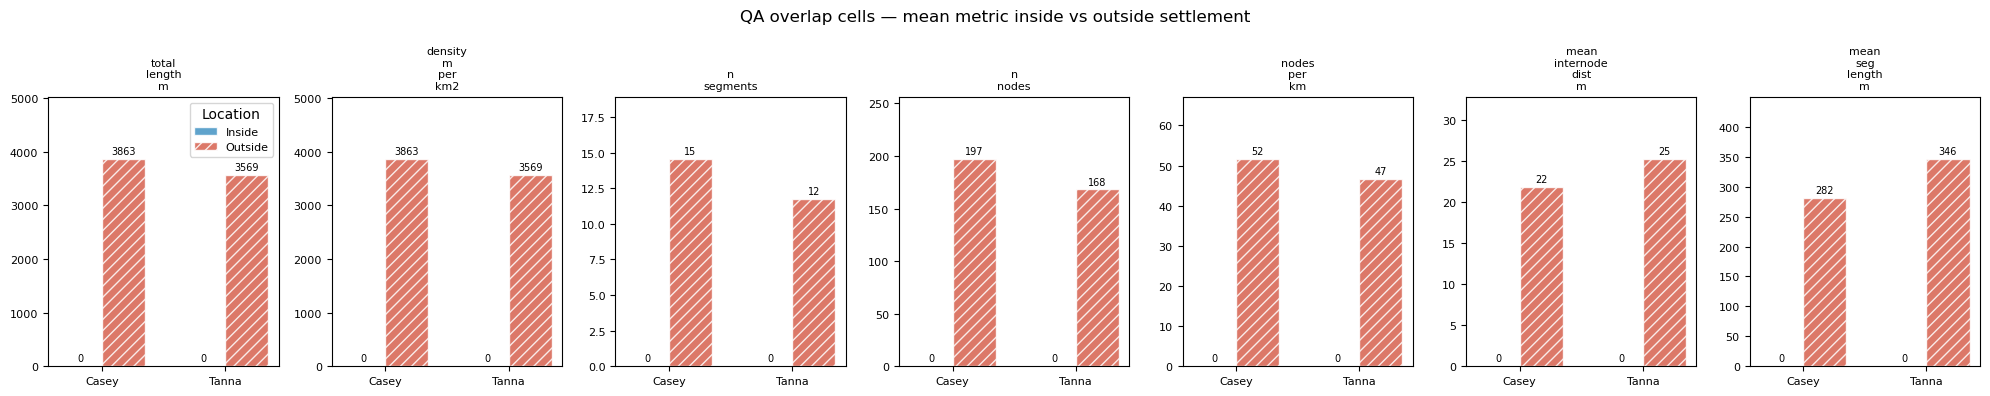

In [61]:
locations = ["Inside", "Outside"]
x_pos = np.arange(len(LABELS))
bar_w = 0.35
agg_loc = cell_metrics.groupby(["location", "participant"])[AGG_COLS].mean()

fig, axes = plt.subplots(1, len(AGG_COLS), figsize=(20, 4))
fig.suptitle("QA overlap cells — mean metric inside vs outside settlement", fontsize=12)
for ax, col in zip(axes, AGG_COLS):
    for offset, loc, color, hatch in [
        (-bar_w / 2, "Inside",  "#4393c3", None),
        ( bar_w / 2, "Outside", "#d6604d", "///"),
    ]:
        vals = [agg_loc.loc[(loc, lbl), col] if (loc, lbl) in agg_loc.index else 0
                for lbl in LABELS]
        bars = ax.bar(x_pos + offset, vals, bar_w,
                      color=color, hatch=hatch, edgecolor="white", label=loc, alpha=0.85)
        ax.bar_label(bars, fmt="%.0f", fontsize=7, padding=2)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(LABELS, fontsize=8)
    ax.set_title(col.replace("_", "\n"), fontsize=8)
    ax.tick_params(labelsize=8)
    ymax = max([agg_loc.loc[(loc, lbl), col]
                for loc in locations for lbl in LABELS
                if (loc, lbl) in agg_loc.index] + [1])
    ax.set_ylim(0, ymax * 1.3)
axes[0].legend(fontsize=8, title="Location")
plt.tight_layout()
savefig("05_qa_overlap_location_bars")
plt.show()

## 5  Pairwise line agreement (F-measure + IoU) on QA overlap cells

**F-measure at threshold T:**
- Sample points every `FMEASURE_SAMPLE_M` m along A's lines
- **Precision** = fraction of A's points within T m of any line in B
- **Recall** = fraction of B's points within T m of any line in A
- **F1** = harmonic mean

Low precision → A drew roads B didn't. Low recall → B drew roads A missed.
Buffered IoU is retained but note it conflates spatial disagreement with coverage
differences and is sensitive to the buffer radius.

In [62]:
def line_fmeasure(lines_A, lines_B, cell_geom, threshold_m, interval_m):
    pts_a = _sample_points_along_lines(lines_A, cell_geom, interval_m)
    pts_b = _sample_points_along_lines(lines_B, cell_geom, interval_m)
    if pts_a is None or pts_b is None:
        return dict(precision=np.nan, recall=np.nan, f1=np.nan)
    tree_b = cKDTree(pts_b)
    tree_a = cKDTree(pts_a)
    dist_ab, _ = tree_b.query(pts_a, workers=-1)
    dist_ba, _ = tree_a.query(pts_b, workers=-1)
    precision = float((dist_ab <= threshold_m).mean())
    recall    = float((dist_ba <= threshold_m).mean())
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return dict(precision=precision, recall=recall, f1=f1)

def _clipped_buffer_union(lines_gdf, cell_geom, buf_m):
    sub = lines_gdf[lines_gdf.intersects(cell_geom)].copy()
    if sub.empty:
        return None
    sub["geometry"] = sub.geometry.intersection(cell_geom)
    sub = sub[~sub.geometry.is_empty]
    return unary_union(sub.geometry.buffer(buf_m)) if not sub.empty else None

def pairwise_iou(lA, lB, cell_geom, buf_m):
    pA = _clipped_buffer_union(lines_gdfs[lA], cell_geom, buf_m)
    pB = _clipped_buffer_union(lines_gdfs[lB], cell_geom, buf_m)
    if pA is None and pB is None:
        return np.nan
    if pA is None or pB is None:
        return 0.0
    u = pA.union(pB).area
    return pA.intersection(pB).area / u if u > 0 else np.nan

agree_rows = []
for _, cell_row in overlap_grid.iterrows():
    oid    = cell_row["OID"]
    geom   = cell_row.geometry
    inside = cell_row["inside_settlement"]
    row    = {"OID": oid, "inside_settlement": inside}
    for (lA, lB) in pairs:
        fm  = line_fmeasure(lines_gdfs[lA], lines_gdfs[lB],
                             geom, FMEASURE_THRESHOLD_M, FMEASURE_SAMPLE_M)
        key = f"{lA.lower()}_{lB.lower()}"
        row[f"prec_{key}"] = fm["precision"]
        row[f"rec_{key}"]  = fm["recall"]
        row[f"f1_{key}"]   = fm["f1"]
        row[f"iou_{key}"]  = pairwise_iou(lA, lB, geom, SNAP_BUFFER_M)
    agree_rows.append(row)

agree_df = pd.DataFrame(agree_rows)
agree_df["location"] = agree_df["inside_settlement"].map(location_label)
f1_cols  = [c for c in agree_df.columns if c.startswith("f1_")]
iou_cols = [c for c in agree_df.columns if c.startswith("iou_")]

agree_summary = agree_df[f1_cols + iou_cols].agg(["mean", "median", "min", "max"])
print(f"F-measure (T={FMEASURE_THRESHOLD_M} m) + IoU (buf={SNAP_BUFFER_M} m):")
display(agree_summary.round(3))
savecsv(agree_summary, "06_qa_fmeasure_iou_summary")

F-measure (T=10 m) + IoU (buf=5 m):


,f1_casey_tanna,iou_casey_tanna
mean,0.81,0.50
median,0.85,0.51
min,0.58,0.28
max,0.90,0.62


  Saved table  → outputs\kiryandongo\casey_vs_tanna\06_qa_fmeasure_iou_summary.csv


In [63]:
loc_agree = agree_df.groupby("location")[f1_cols + iou_cols].agg(["mean", "median"])
print("=== F-measure / IoU by inside/outside settlement ===")
display(loc_agree.round(3))
savecsv(loc_agree, "07_qa_fmeasure_iou_by_location")

=== F-measure / IoU by inside/outside settlement ===


f1_casey_tanna        iou_casey_tanna       
                   mean median            mean median
location                                             
Outside            0.81   0.85            0.50   0.51

  Saved table  → outputs\kiryandongo\casey_vs_tanna\07_qa_fmeasure_iou_by_location.csv


  Saved figure → outputs\kiryandongo\casey_vs_tanna\08_fmeasure_iou_hist_casey_tanna.png


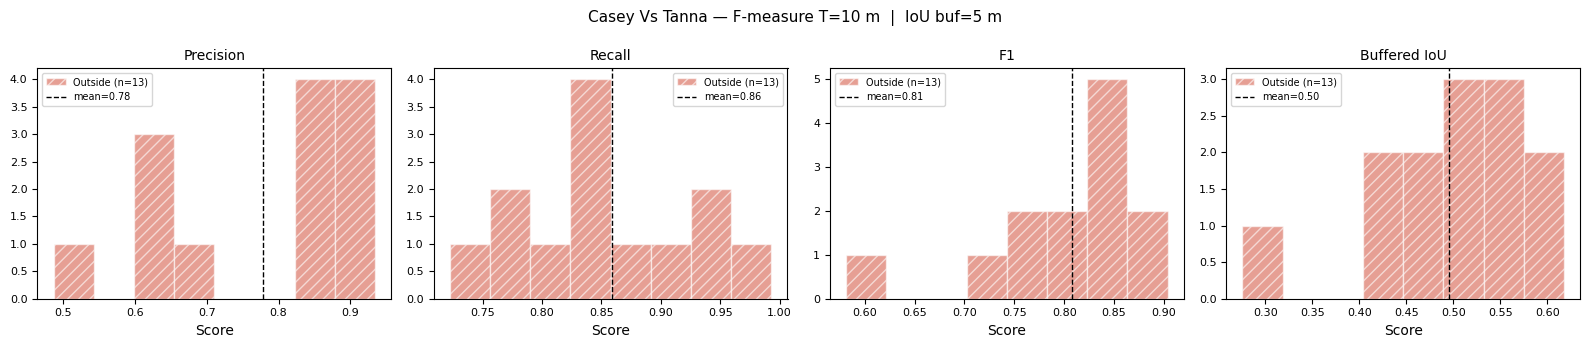

In [64]:
for pair_key in [c.replace("f1_", "") for c in f1_cols]:
    prec_col   = f"prec_{pair_key}"
    rec_col    = f"rec_{pair_key}"
    f1_col     = f"f1_{pair_key}"
    iou_col    = f"iou_{pair_key}"
    pair_label = pair_key.replace("_", " vs ").title()

    fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
    fig.suptitle(
        f"{pair_label} — F-measure T={FMEASURE_THRESHOLD_M} m  |  IoU buf={SNAP_BUFFER_M} m",
        fontsize=11
    )
    for ax, col, title in zip(
        axes,
        [prec_col, rec_col, f1_col, iou_col],
        ["Precision", "Recall", "F1", "Buffered IoU"],
    ):
        for loc, color, hatch in [("Inside", "#4393c3", None), ("Outside", "#d6604d", "///")]:
            vals = agree_df.loc[agree_df["location"] == loc, col].dropna()
            if not vals.empty:
                ax.hist(vals, bins=8, alpha=0.6, color=color, hatch=hatch,
                        edgecolor="white", label=f"{loc} (n={len(vals)})")
        ax.axvline(agree_df[col].mean(), color="black", linestyle="--", linewidth=1,
                   label=f"mean={agree_df[col].mean():.2f}")
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("Score")
        ax.legend(fontsize=7)
        ax.tick_params(labelsize=8)
    plt.tight_layout()
    savefig(f"08_fmeasure_iou_hist_{pair_key}")
    plt.show()

  Saved figure → outputs\kiryandongo\casey_vs_tanna\09_prec_recall_scatter_casey_tanna.png


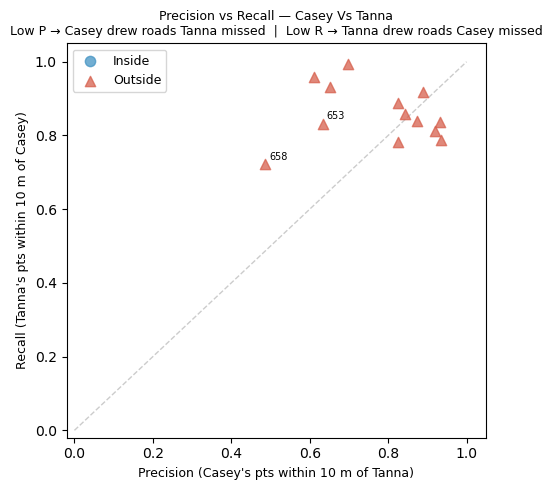

In [65]:
for pair_key in [c.replace("f1_", "") for c in f1_cols]:
    prec_col   = f"prec_{pair_key}"
    rec_col    = f"rec_{pair_key}"
    f1_col     = f"f1_{pair_key}"
    pair_label = pair_key.replace("_", " vs ").title()
    lA, lB     = [s.capitalize() for s in pair_key.split("_")]

    fig, ax = plt.subplots(figsize=(5, 5))
    for loc, color, marker in [("Inside", "#4393c3", "o"), ("Outside", "#d6604d", "^")]:
        sub = agree_df[agree_df["location"] == loc]
        ax.scatter(sub[prec_col], sub[rec_col],
                   color=color, marker=marker, alpha=0.75, s=55, label=loc, zorder=3)
        for _, row in sub.nsmallest(2, f1_col).iterrows():
            ax.annotate(str(int(row["OID"])), (row[prec_col], row[rec_col]),
                        fontsize=7, xytext=(3, 3), textcoords="offset points")
    ax.plot([0, 1], [0, 1], "--", color="#cccccc", linewidth=1)
    ax.set_xlim(-0.02, 1.05)
    ax.set_ylim(-0.02, 1.05)
    ax.set_xlabel(f"Precision ({lA}'s pts within {FMEASURE_THRESHOLD_M} m of {lB})", fontsize=9)
    ax.set_ylabel(f"Recall ({lB}'s pts within {FMEASURE_THRESHOLD_M} m of {lA})",    fontsize=9)
    ax.set_title(f"Precision vs Recall — {pair_label}\n"
                 f"Low P → {lA} drew roads {lB} missed  |  Low R → {lB} drew roads {lA} missed",
                 fontsize=9)
    ax.legend(fontsize=9)
    plt.tight_layout()
    savefig(f"09_prec_recall_scatter_{pair_key}")
    plt.show()

## 6  Individual QA cell maps — lowest F1

  Saved figure → outputs\kiryandongo\casey_vs_tanna\10_low_f1_cells_casey_tanna.png


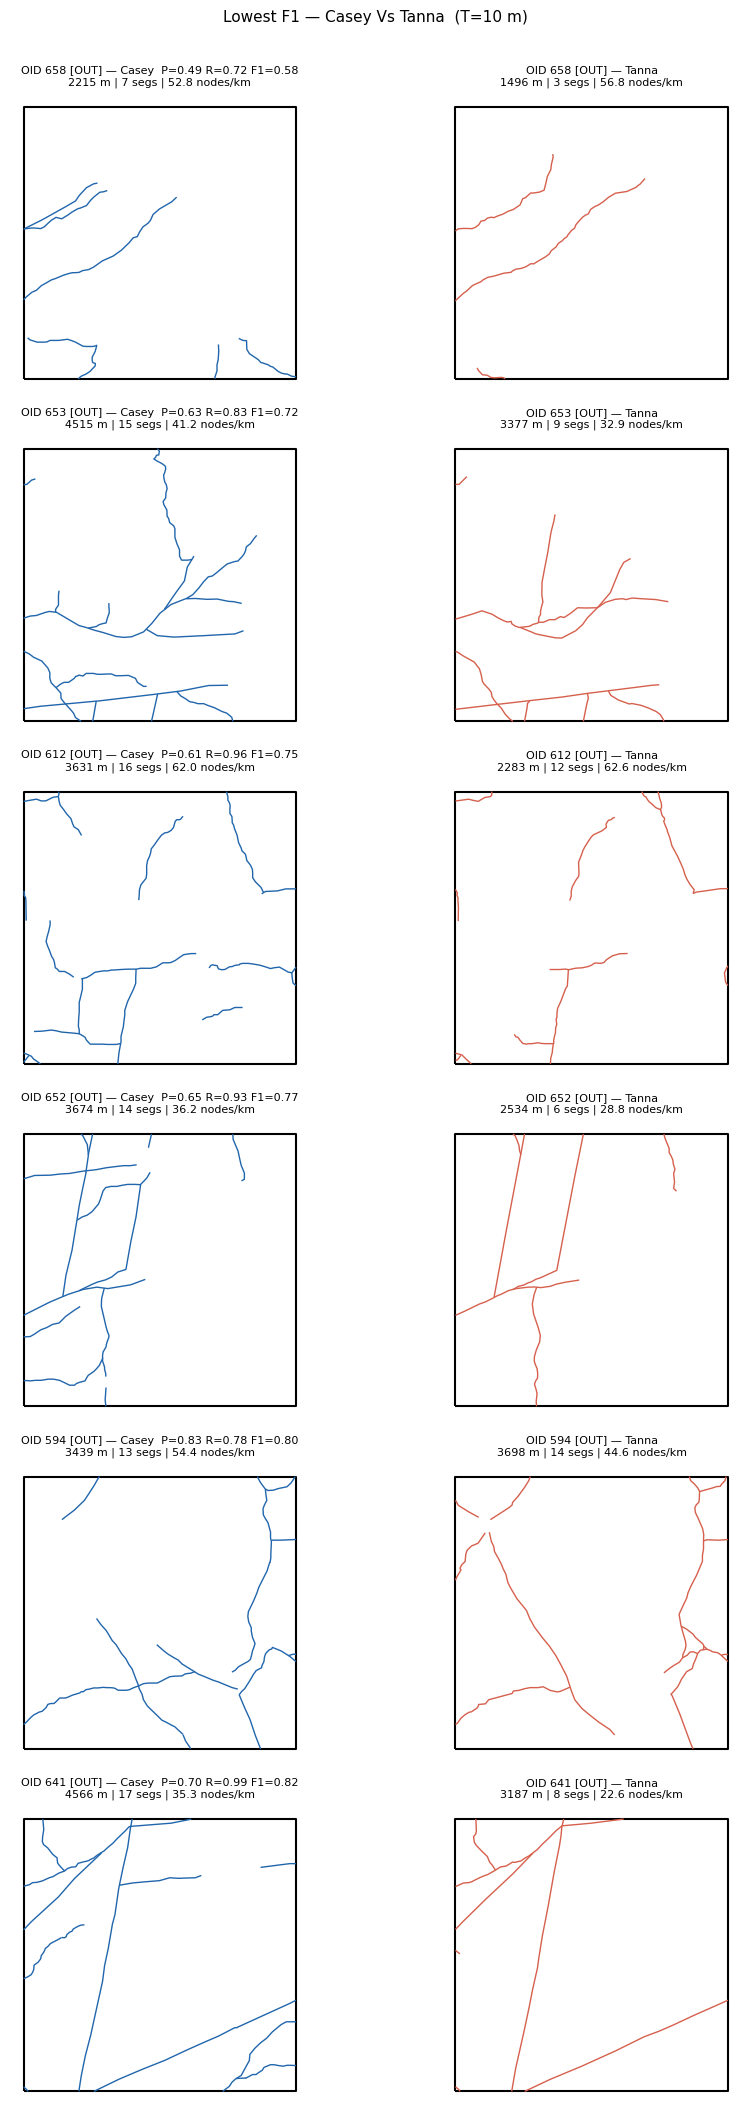

In [66]:
def _plot_cell(ax, label, oid, cell_geom, title_extra=""):
    gpd.GeoSeries([cell_geom]).boundary.plot(ax=ax, color="black", linewidth=1.5, zorder=1)
    clipped = lines_gdfs[label][lines_gdfs[label].intersects(cell_geom)].copy()
    if not clipped.empty:
        clipped["geometry"] = clipped.geometry.intersection(cell_geom)
        clipped = clipped[~clipped.geometry.is_empty]
    if not clipped.empty:
        clipped.plot(ax=ax, color=COLORS[label], linewidth=1.0, zorder=2)
    m = cell_metrics[
        (cell_metrics["OID"] == oid) & (cell_metrics["participant"] == label)
    ].iloc[0]
    loc_str = "IN" if m.inside_settlement else "OUT"
    ax.set_title(
        f"OID {oid} [{loc_str}] — {label}{title_extra}\n"
        f"{m.total_length_m:.0f} m | {m.n_segments} segs | "
        f"{m.nodes_per_km:.1f} nodes/km",
        fontsize=8,
    )
    ax.set_axis_off()

for pair_key in [c.replace("f1_", "") for c in f1_cols]:
    f1_col     = f"f1_{pair_key}"
    prec_col   = f"prec_{pair_key}"
    rec_col    = f"rec_{pair_key}"
    pair_label = pair_key.replace("_", " vs ").title()
    lA, lB     = [s.capitalize() for s in pair_key.split("_")]
    low_oids   = agree_df.nsmallest(N_EXAMPLE_CELLS, f1_col)["OID"].tolist()

    fig, axes = plt.subplots(N_EXAMPLE_CELLS, 2,
                             figsize=(10, N_EXAMPLE_CELLS * 3.5), squeeze=False)
    fig.suptitle(f"Lowest F1 — {pair_label}  (T={FMEASURE_THRESHOLD_M} m)",
                 fontsize=11, y=1.005)
    for row_i, oid in enumerate(low_oids):
        cell_geom = overlap_grid.loc[overlap_grid["OID"] == oid, "geometry"].values[0]
        ag = agree_df.loc[agree_df["OID"] == oid].iloc[0]
        for col_i, label in enumerate([lA, lB]):
            extra = (f"  P={ag[prec_col]:.2f} R={ag[rec_col]:.2f} F1={ag[f1_col]:.2f}"
                     if col_i == 0 else "")
            _plot_cell(axes[row_i, col_i], label, oid, cell_geom, extra)
    plt.tight_layout()
    savefig(f"10_low_f1_cells_{pair_key}")
    plt.show()

## 7  Per-cell detail table

In [67]:
wide = cell_metrics.pivot(index="OID", columns="participant", values=AGG_COLS)
wide.columns = [f"{metric}_{p.lower()}" for metric, p in wide.columns]
wide = wide.reset_index()
wide = wide.merge(
    overlap_grid[["OID", "inside_settlement"]].assign(
        location=overlap_grid["inside_settlement"].map(location_label)
    ),
    on="OID", how="left",
)
wide = wide.merge(agree_df[["OID"] + f1_cols + iou_cols], on="OID", how="left")
for col in AGG_COLS:
    p_cols = [f"{col}_{p.lower()}" for p in LABELS]
    wide[f"{col}_range"] = wide[p_cols].max(axis=1) - wide[p_cols].min(axis=1)
wide = wide.sort_values(f1_cols[0] if f1_cols else "total_length_m_range", ascending=True)
print("=== Per-cell detail table (sorted by lowest F1) ===")
display(wide.drop(columns="inside_settlement").round(3))
savecsv(wide.drop(columns="inside_settlement"), "11_qa_percell_detail")

=== Per-cell detail table (sorted by lowest F1) ===


,OID,total_length_m_casey,total_length_m_tanna,density_m_per_km2_casey,density_m_per_km2_tanna,n_segments_casey,n_segments_tanna,n_nodes_casey,n_nodes_tanna,nodes_per_km_casey,nodes_per_km_tanna,mean_internode_dist_m_casey,mean_internode_dist_m_tanna,mean_seg_length_m_casey,mean_seg_length_m_tanna,location,f1_casey_tanna,iou_casey_tanna,total_length_m_range,density_m_per_km2_range,n_segments_range,n_nodes_range,nodes_per_km_range,mean_internode_dist_m_range,mean_seg_length_m_range
12,658,2215.16,1496.27,2215.16,1496.27,7.00,3.00,117.00,85.00,52.82,56.81,20.14,18.25,316.45,498.76,Outside,0.58,0.28,718.89,718.89,4.00,32.00,3.99,1.89,182.31
11,653,4514.90,3377.49,4514.90,3377.49,15.00,9.00,186.00,111.00,41.20,32.87,26.40,33.11,300.99,375.28,Outside,0.72,0.41,1137.41,1137.41,6.00,75.00,8.33,6.71,74.28
5,612,3631.36,2283.38,3631.36,2283.38,16.00,12.00,225.00,143.00,61.96,62.63,17.38,17.43,226.96,190.28,Outside,0.75,0.45,1347.97,1347.97,4.00,82.00,0.67,0.06,36.68
10,652,3674.13,2533.95,3674.13,2533.95,14.00,6.00,133.00,73.00,36.20,28.81,30.88,37.82,262.44,422.32,Outside,0.77,0.44,1140.18,1140.18,8.00,60.00,7.39,6.95,159.89
2,594,3438.62,3698.39,3438.62,3698.39,13.00,14.00,187.00,165.00,54.38,44.61,19.76,24.49,264.51,264.17,Outside,0.80,0.49,259.76,259.76,1.00,22.00,9.77,4.73,0.34
8,641,4566.34,3187.44,4566.34,3187.44,17.00,8.00,161.00,72.00,35.26,22.59,31.71,49.80,268.61,398.43,Outside,0.82,0.48,1378.91,1378.91,9.00,89.00,12.67,18.09,129.82
7,628,3176.27,3157.32,3176.27,3157.32,18.00,15.00,188.00,158.00,59.19,50.04,18.68,22.08,176.46,210.49,Outside,0.85,0.52,18.94,18.94,3.00,30.00,9.15,3.40,34.03
6,627,4649.61,5686.69,4649.61,5686.69,19.00,19.00,254.00,299.00,54.63,52.58,19.79,20.31,244.72,299.30,Outside,0.85,0.55,1037.07,1037.07,0.00,45.00,2.05,0.52,54.58
4,611,6251.92,5874.23,6251.92,5874.23,18.00,19.00,318.00,344.00,50.86,58.56,20.84,18.07,347.33,309.17,Outside,0.85,0.55,377.69,377.69,1.00,26.00,7.70,2.77,38.16
1,577,1866.36,1948.34,1866.36,1948.34,4.00,3.00,89.00,94.00,47.69,48.25,21.96,21.41,466.59,649.45,Outside,0.86,0.51,81.98,81.98,1.00,5.00,0.56,0.55,182.86


  Saved table  → outputs\kiryandongo\casey_vs_tanna\11_qa_percell_detail.csv


## 8  Random QA cell explorer

Re-run to see a new random overlap cell. Set `RANDOM_OID` to an integer to pin a cell.

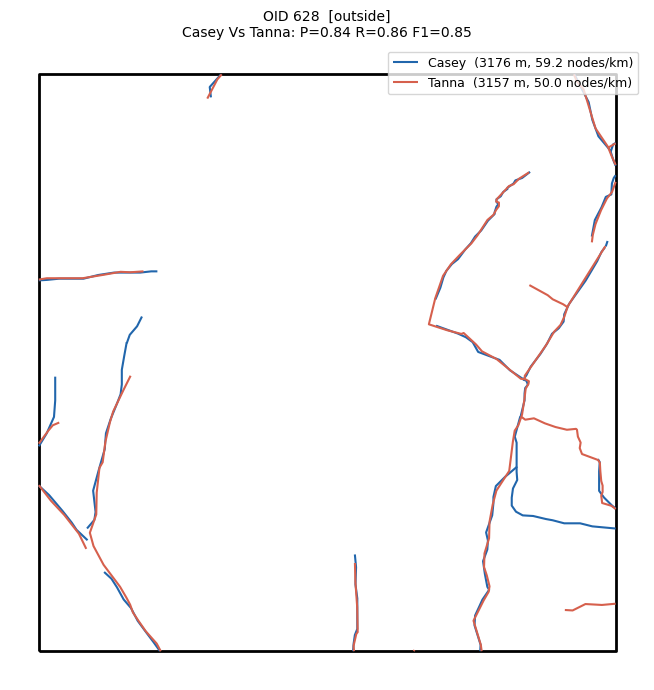

OID 628 (outside settlement)


In [68]:
RANDOM_OID = None  # None = random each run

rng = np.random.default_rng()
oid = int(rng.choice(overlap_oids)) if RANDOM_OID is None else RANDOM_OID

cell_geom = overlap_grid.loc[overlap_grid["OID"] == oid, "geometry"].values[0]
inside    = overlap_grid.loc[overlap_grid["OID"] == oid, "inside_settlement"].values[0]
ag_row    = agree_df.loc[agree_df["OID"] == oid].iloc[0] if len(agree_df) else None

fig, ax = plt.subplots(figsize=(7, 7))
gpd.GeoSeries([cell_geom]).boundary.plot(ax=ax, color="black", linewidth=2.0, zorder=1)
clip_bnd = settlement.clip(cell_geom)
if not clip_bnd.empty:
    clip_bnd.boundary.plot(ax=ax, color="#888888", linewidth=1.2,
                           linestyle="--", zorder=2, label="settlement boundary")
for label in LABELS:
    clipped = lines_gdfs[label][lines_gdfs[label].intersects(cell_geom)].copy()
    if not clipped.empty:
        clipped["geometry"] = clipped.geometry.intersection(cell_geom)
        clipped = clipped[~clipped.geometry.is_empty]
    if not clipped.empty:
        m = cell_metrics[
            (cell_metrics["OID"] == oid) & (cell_metrics["participant"] == label)
        ].iloc[0]
        clipped.plot(ax=ax, color=COLORS[label], linewidth=1.5, zorder=3,
                     label=f"{label}  ({m.total_length_m:.0f} m, "
                           f"{m.nodes_per_km:.1f} nodes/km)")

loc_str = "inside" if inside else "outside"
score_strs = []
if ag_row is not None:
    for pair_key in [c.replace("f1_", "") for c in f1_cols]:
        pl = pair_key.replace("_", " vs ").title()
        score_strs.append(
            f"{pl}: P={ag_row[f'prec_{pair_key}']:.2f} "
            f"R={ag_row[f'rec_{pair_key}']:.2f} F1={ag_row[f'f1_{pair_key}']:.2f}"
        )
ax.set_title(f"OID {oid}  [{loc_str}]\n" + "\n".join(score_strs), fontsize=10)
ax.legend(fontsize=9, loc="upper right")
ax.set_axis_off()
plt.tight_layout()
plt.show()
print(f"OID {oid} ({loc_str} settlement)")

---
## 9  Intra-digitizer — full assignment (inside vs outside settlement)

Each participant analysed independently over their entire assignment. Because inside
and outside are different cells (not matched pairs), Welch's t-test is used.

In [69]:
full_rows = []
for label, g in all_assigned_grids.items():
    lines_gdf = lines_gdfs[label]
    for _, cell_row in g.iterrows():
        full_rows.append({
            "OID"               : cell_row["OID"],
            "participant"       : label,
            "inside_settlement" : cell_row["inside_settlement"],
            "is_overlap"        : cell_row["is_overlap"],
            **metrics_for_lines_in_cell(lines_gdf, cell_row.geometry),
        })

full_metrics = pd.DataFrame(full_rows)
full_metrics["location"] = full_metrics["inside_settlement"].map(location_label)
print("Full assignment cell counts:")
print(full_metrics.groupby(["participant", "location"])["OID"].count().rename("n_cells").to_string())

Full assignment cell counts:
participant  location
Casey        Inside       40
             Outside     193
Tanna        Inside        1
             Outside     231


In [70]:
full_agg = full_metrics.groupby(["participant", "location"])[AGG_COLS].mean().round(2)
print("=== Full assignment — mean metrics by participant and location ===")
display(full_agg)
savecsv(full_agg, "12_full_assignment_location_means")

=== Full assignment — mean metrics by participant and location ===


total_length_m  density_m_per_km2  n_segments  n_nodes  \
participant location                                                           
Casey       Inside           4264.94            4264.94       18.08   203.72   
            Outside          2344.61            2344.61        9.34    87.64   
Tanna       Inside           6238.16            6238.16       33.00   270.00   
            Outside          2667.57            2667.57       12.29   118.06   

                      nodes_per_km  mean_internode_dist_m  mean_seg_length_m  
participant location                                                          
Casey       Inside           48.40                  23.21             243.71  
            Outside          40.83                  30.73             253.44  
Tanna       Inside           43.28                  26.32             189.04  
            Outside          44.18                  26.85             235.24

  Saved table  → outputs\kiryandongo\casey_vs_tanna\12_full_assignment_location_means.csv


In [71]:
full_intra_rows = []
for label in LABELS:
    sub = full_metrics[full_metrics["participant"] == label]
    for col in AGG_COLS:
        v_in  = sub[sub["inside_settlement"]][col].dropna().values
        v_out = sub[~sub["inside_settlement"]][col].dropna().values
        if len(v_in) < 2 or len(v_out) < 2:
            continue
        _, p = stats.ttest_ind(v_in, v_out, equal_var=False)
        full_intra_rows.append(dict(
            participant=label, metric=col,
            mean_inside=v_in.mean(), mean_outside=v_out.mean(),
            ratio_in_out=v_in.mean() / v_out.mean() if v_out.mean() != 0 else np.nan,
            n_inside=len(v_in), n_outside=len(v_out), ttest_p=p, significant=p < 0.05,
        ))
full_intra_df = pd.DataFrame(full_intra_rows)
print("=== Welch t-test: inside vs outside (full assignment) ===")
display(full_intra_df.round(4))
savecsv(full_intra_df, "13_full_assignment_intra_tests")

=== Welch t-test: inside vs outside (full assignment) ===


,participant,metric,mean_inside,mean_outside,ratio_in_out,n_inside,n_outside,ttest_p,significant
0,Casey,total_length_m,4264.94,2344.61,1.82,40,193,0.00,True
1,Casey,density_m_per_km2,4264.94,2344.61,1.82,40,193,0.00,True
2,Casey,n_segments,18.07,9.34,1.93,40,193,0.00,True
3,Casey,n_nodes,203.72,87.64,2.32,40,193,0.00,True
4,Casey,nodes_per_km,48.40,40.83,1.19,37,118,0.00,True
5,Casey,mean_internode_dist_m,23.21,30.73,0.76,37,118,0.00,True
6,Casey,mean_seg_length_m,243.71,253.44,0.96,37,118,0.46,False


  Saved table  → outputs\kiryandongo\casey_vs_tanna\13_full_assignment_intra_tests.csv


  Saved figure → outputs\kiryandongo\casey_vs_tanna\14_full_assignment_boxplots.png


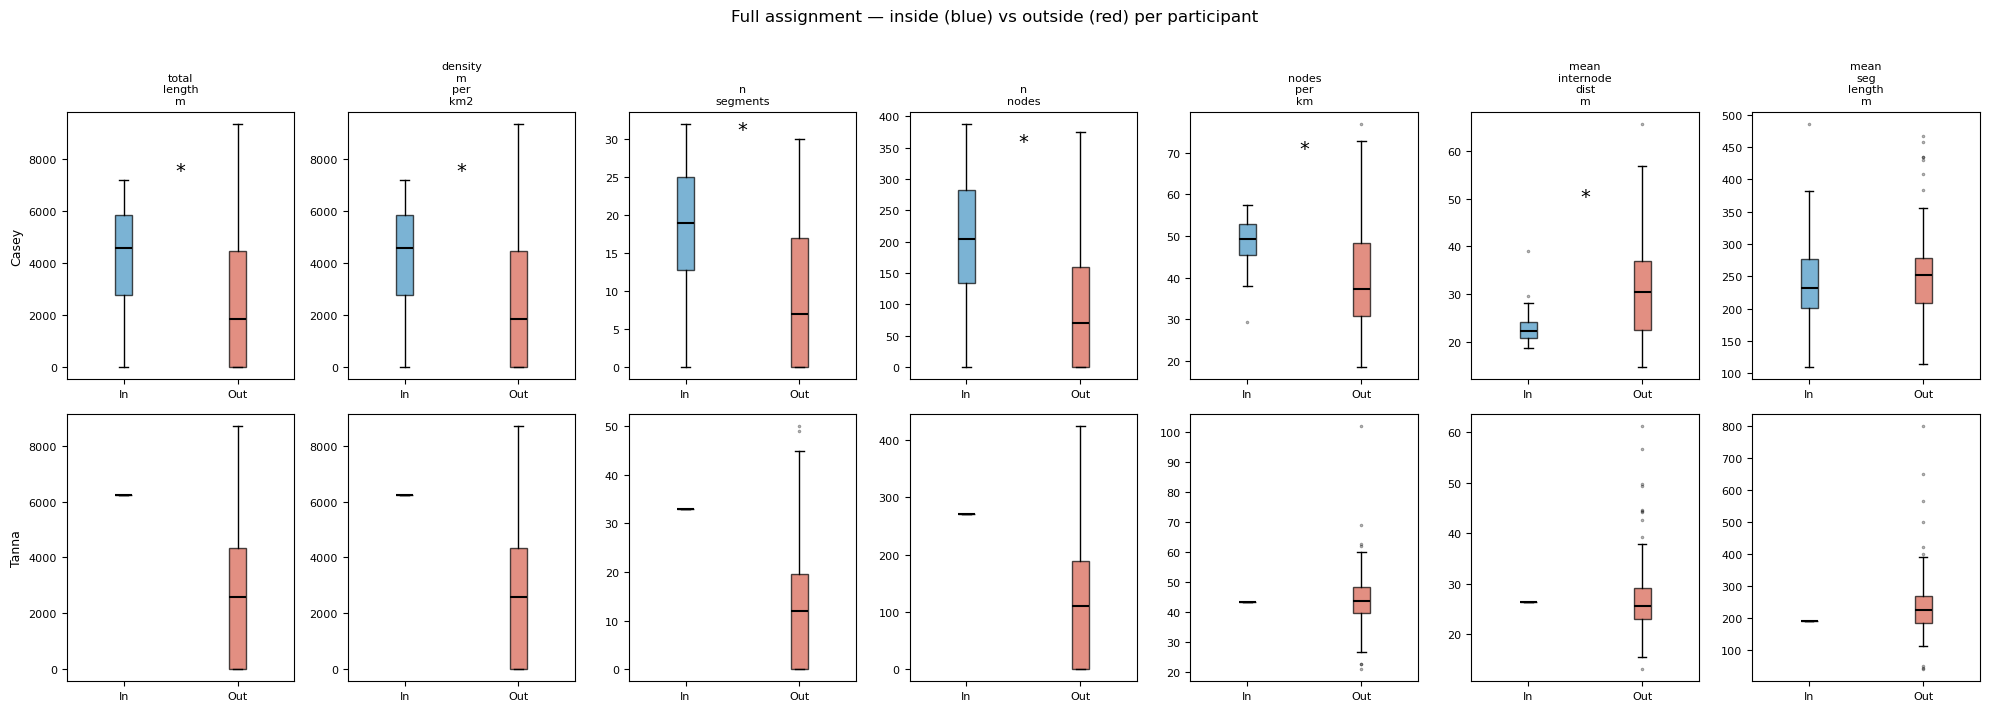

In [72]:
n_rows = len(LABELS)
fig, axes = plt.subplots(n_rows, len(AGG_COLS),
                         figsize=(20, n_rows * 3.5), squeeze=False)
fig.suptitle("Full assignment — inside (blue) vs outside (red) per participant",
             fontsize=12, y=1.01)

for row_i, label in enumerate(LABELS):
    sub = full_metrics[full_metrics["participant"] == label]
    for col_i, col in enumerate(AGG_COLS):
        ax = axes[row_i, col_i]
        data_in  = sub[sub["inside_settlement"]][col].dropna().values
        data_out = sub[~sub["inside_settlement"]][col].dropna().values
        bp = ax.boxplot([data_in, data_out], labels=["In", "Out"],
                        patch_artist=True,
                        medianprops=dict(color="black", linewidth=1.5),
                        flierprops=dict(marker=".", markersize=3, alpha=0.4))
        for patch, color in zip(bp["boxes"], ["#4393c3", "#d6604d"]):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        mask = ((full_intra_df["participant"] == label) & (full_intra_df["metric"] == col))
        if mask.any() and full_intra_df.loc[mask, "significant"].values[0]:
            y_top = max(
                np.percentile(data_in,  95) if len(data_in)  else 0,
                np.percentile(data_out, 95) if len(data_out) else 0,
            )
            ax.text(1.5, y_top * 1.05, "*", ha="center", fontsize=14)
        if row_i == 0:
            ax.set_title(col.replace("_", "\n"), fontsize=8)
        if col_i == 0:
            ax.set_ylabel(label, fontsize=9)
        ax.tick_params(labelsize=8)

plt.tight_layout()
savefig("14_full_assignment_boxplots")
plt.show()

  Saved figure → outputs\kiryandongo\casey_vs_tanna\15_full_assignment_location_bars.png


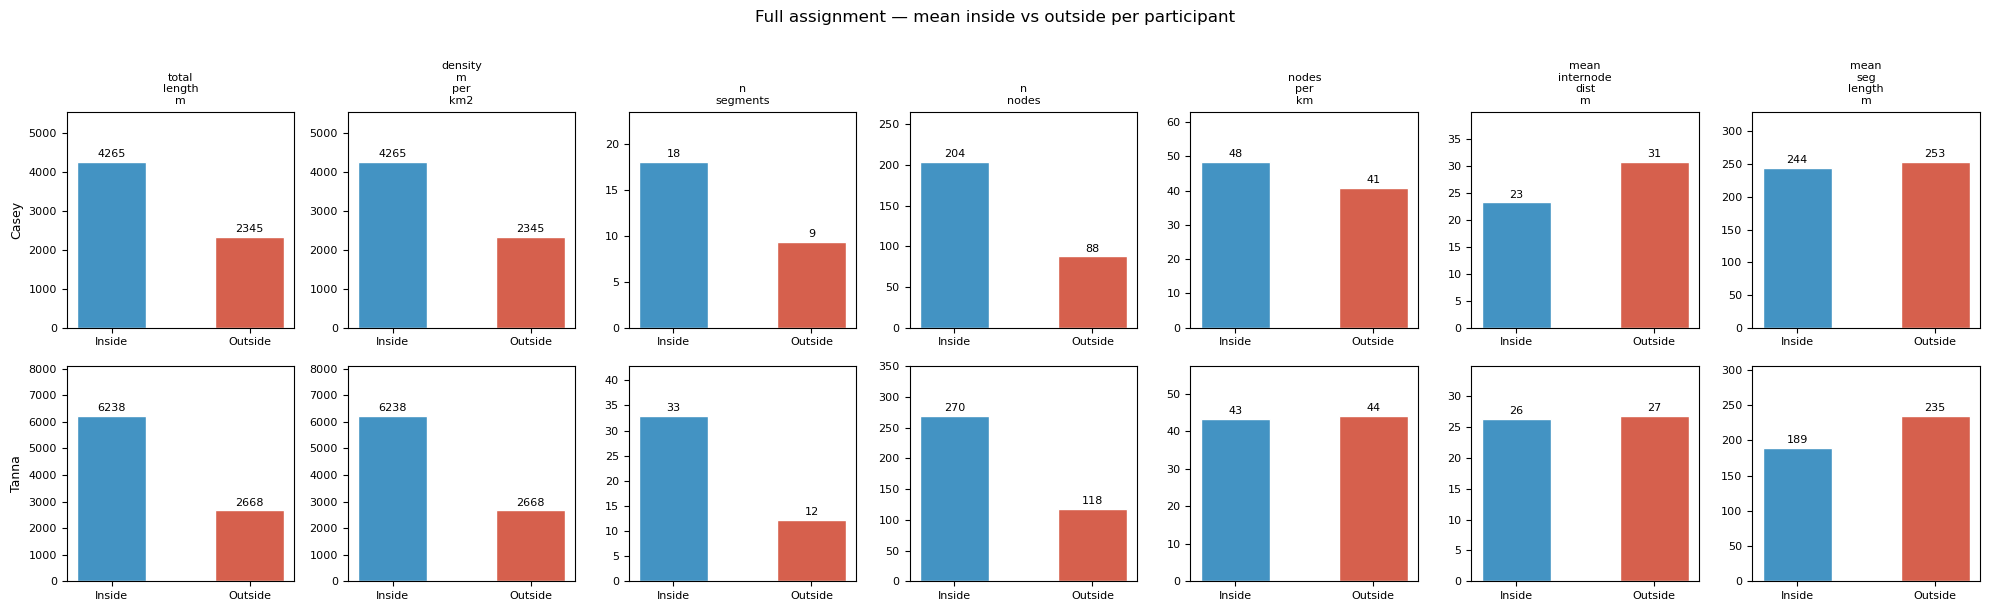

In [73]:
fig, axes = plt.subplots(len(LABELS), len(AGG_COLS),
                         figsize=(20, len(LABELS) * 3), squeeze=False)
fig.suptitle("Full assignment — mean inside vs outside per participant",
             fontsize=12, y=1.01)
fa = full_metrics.groupby(["participant", "location"])[AGG_COLS].mean()
for row_i, label in enumerate(LABELS):
    for col_i, col in enumerate(AGG_COLS):
        ax = axes[row_i, col_i]
        vals = [fa.loc[(label, loc), col] if (label, loc) in fa.index else 0
                for loc in locations]
        bars = ax.bar(locations, vals, color=["#4393c3", "#d6604d"],
                      edgecolor="white", width=0.5)
        ax.bar_label(bars, fmt="%.0f", fontsize=8, padding=2)
        if row_i == 0:
            ax.set_title(col.replace("_", "\n"), fontsize=8)
        if col_i == 0:
            ax.set_ylabel(label, fontsize=9)
        ax.set_ylim(0, max(vals + [1]) * 1.3)
        ax.tick_params(labelsize=8)
plt.tight_layout()
savefig("15_full_assignment_location_bars")
plt.show()

  Saved figure → outputs\kiryandongo\casey_vs_tanna\16_full_assignment_length_hist.png


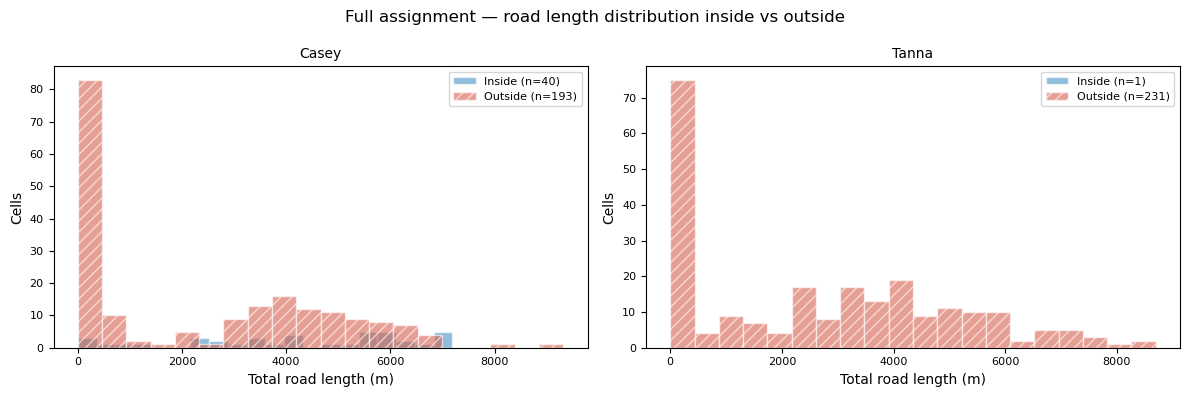

In [74]:
fig, axes = plt.subplots(1, len(LABELS), figsize=(6 * len(LABELS), 4), squeeze=False)
fig.suptitle("Full assignment — road length distribution inside vs outside", fontsize=12)
for ax, label in zip(axes[0], LABELS):
    sub = full_metrics[full_metrics["participant"] == label]
    for loc, color, hatch in [("Inside", "#4393c3", None), ("Outside", "#d6604d", "///")]:
        vals = sub[sub["location"] == loc]["total_length_m"].dropna()
        if not vals.empty:
            ax.hist(vals, bins=20, alpha=0.6, color=color, hatch=hatch,
                    edgecolor="white", label=f"{loc} (n={len(vals)})")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Total road length (m)")
    ax.set_ylabel("Cells")
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)
plt.tight_layout()
savefig("16_full_assignment_length_hist")
plt.show()

---
## 10  Pairwise scatter plots — QA overlap cells

  Saved figure → outputs\kiryandongo\casey_vs_tanna\17_pairwise_scatter.png


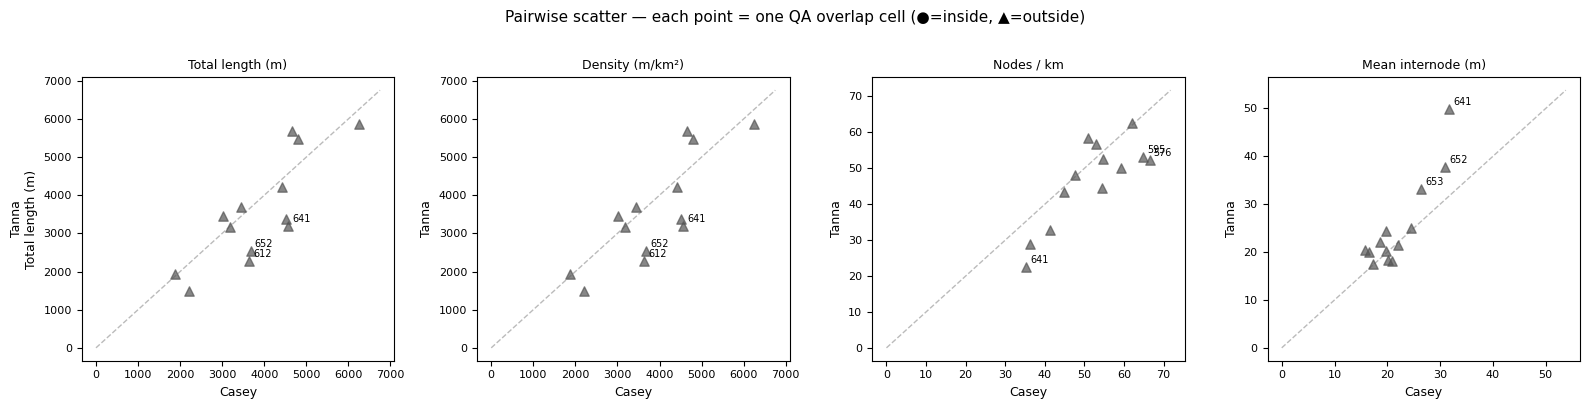

In [75]:
KEY_METRICS = [
    ("total_length_m",       "Total length (m)"),
    ("density_m_per_km2",    "Density (m/km\u00b2)"),
    ("nodes_per_km",         "Nodes / km"),
    ("mean_internode_dist_m","Mean internode (m)"),
]
inside_oids  = set(overlap_grid[overlap_grid["inside_settlement"]]["OID"])
marker_style = ["o" if oid in inside_oids else "^" for oid in overlap_oids]

fig, axes = plt.subplots(len(pairs), len(KEY_METRICS),
                         figsize=(len(KEY_METRICS) * 4, len(pairs) * 4),
                         squeeze=False)
for row_i, (lA, lB) in enumerate(pairs):
    for col_i, (col, label) in enumerate(KEY_METRICS):
        ax = axes[row_i, col_i]
        x  = vals_by_p[lA].loc[overlap_oids, col].values
        y  = vals_by_p[lB].loc[overlap_oids, col].values
        for xi, yi, mk in zip(x, y, marker_style):
            ax.scatter(xi, yi, marker=mk, color="#555555", alpha=0.7, s=45, zorder=3)
        valid = ~(np.isnan(x) | np.isnan(y))
        if valid.any():
            lim = max(np.nanmax(x), np.nanmax(y)) * 1.08
            ax.plot([0, lim], [0, lim], "--", color="#bbbbbb", linewidth=1, zorder=1)
        diffs = np.abs(x - y)
        for i in np.argsort(np.where(np.isnan(diffs), -1, diffs))[-3:]:
            ax.annotate(str(overlap_oids[i]), (x[i], y[i]),
                        fontsize=7, xytext=(3, 3), textcoords="offset points")
        ax.set_xlabel(lA, fontsize=9)
        ax.set_ylabel(f"{lB}\n{label}" if col_i == 0 else lB, fontsize=9)
        ax.set_title(label if row_i == 0 else "", fontsize=9)
        ax.tick_params(labelsize=8)
fig.suptitle("Pairwise scatter — each point = one QA overlap cell (\u25cf=inside, \u25b2=outside)",
             fontsize=11, y=1.01)
plt.tight_layout()
savefig("17_pairwise_scatter")
plt.show()